# Setup & Imports

In [1]:
import os
import operator

from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from pathlib import Path
from dotenv import load_dotenv

c:\Users\ok\OneDrive\Documents\Agentic AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
load_dotenv()

# LLM Configuration

In [14]:
llm = ChatGroq( 
    model = 'llama-3.3-70b-versatile',
    temperature= 0
)

# Pydantic Model & Schemas

In [15]:
class Task(BaseModel):
    id : int
    title : str
    description : str = Field(description= 'What to cover tough.')
    goal : str = Field(description= 'One sentence describing what the reader should be able to understand after this.')
    target_words : int = Field(description= 'Max Length of words for this section is (400-600)')    
    bullets : List[str] = Field(
        description= 'Between 5-8 concrete, non-overlapping points to cover this section.'
    )

In [16]:
class Plan(BaseModel):
    blog_title : str
    tasks : List[Task]
    audience : str = Field(description= 'What kind of people can relate to this blog.')
    tone : str = Field(description= 'What quality of language the blog contain(proffesional, fluent etc)')

In [17]:
class BlogState(TypedDict):
    topic : str
    plan : Plan
    sections : Annotated[List[str], operator.add]
    final : str

In [18]:
struct_llm = llm.with_structured_output(Plan)

# Orchestrator Node(Planner)

In [19]:
def orchestrator(state: BlogState):
    plan = struct_llm.invoke(
        [
            SystemMessage(content="""You are an expert content strategist and blog architect.

Your task is to create a comprehensive, well-structured blog plan with 5–6 sections.

For each Task section, you MUST provide exactly these fields:
- id: sequential integer starting from 1
- title: a compelling, SEO-friendly section heading
- description: 1–2 sentences on what this section covers (be specific, not vague)
- goal: one sentence — what the reader will understand after reading this section
- target_words: an integer between 400 and 600
- bullets: 5–8 concrete, non-overlapping points that the writer must cover in this section

For the overall Plan, also provide:
- blog_title: an engaging, specific title for the full blog post
- audience: describe the target reader (e.g. "software engineers new to AI agents")
- tone: writing style to use (e.g. "professional but approachable")

Follow these structural principles:
1. Section 1 → Hook: why this topic matters right now
2. Sections 2–3 → Foundation: core concepts, clearly defined
3. Sections 4–5 → Depth: advanced insights, real-world application
4. Section 6 → Close: summary and call to action

Ensure each section's bullets are self-contained enough for a writer to work from independently."""),
            HumanMessage(content=f'Topic: {state["topic"]}'),
        ]
    )
    return {'plan': plan}

# Parallel Working

In [20]:
def distribute_tasks(state: BlogState):
# The 'Send' command is use to send your plan(plan contain tasks) to 'worker' node for processing    
    return [Send('worker', {'task': task, 'topic': state['topic'], 'plan': state['plan']})
            for task in state['plan'].tasks]

In [ ]:
# Worker uses 'Send' command due to which it's special & we use (payload : dict)
def worker(payload: dict) -> dict:
    tasks = payload['task']
    topic = payload['topic']
    plan = payload['plan']

    blog_title = plan.blog_title
    bullet_text = '\n\n'.join(tasks.bullets)

    sections = llm.invoke(
        [
            SystemMessage(content="""You are an expert technical blog writer specializing in clear, engaging markdown content.

Your task is to write ONE complete blog section in clean markdown.

Writing guidelines:
- Match tone to the section's purpose: educational for concepts, conversational for intros, precise for technical content
- Use **bold** for key terms on first mention
- Include smooth transitions at the end of each section to hint at what's next
- Prefer concrete examples over abstract explanations
- Keep paragraphs under 5 lines for readability

Formatting rules:
- Use `##` for the section heading (never `#` — that's reserved for the blog title)
- Use `###` for sub-headings if needed
- Use bullet lists only for genuinely enumerable items (3+ items), not as a crutch
- Use code blocks (``` ```) for any code, commands, or technical syntax
- Never add a preamble like "Here is the section..." — output markdown only

Diagram rules (use when it genuinely aids understanding):
- If the section involves a process, flow, architecture, or hierarchy → include a Mermaid diagram
- Wrap diagrams in a ```mermaid code fence
- Diagram types to use:
    • flowchart TD  → for processes and decision trees
    • sequenceDiagram → for interactions between components
    • classDiagram   → for structures and relationships
    • graph LR       → for pipelines and linear flows
- Keep diagrams simple: max 8 nodes, clear labels, no redundant edges
- Place the diagram AFTER the introductory paragraph, before the deep-dive prose
- Only include a diagram if it genuinely clarifies — skip it for opinion or narrative sections"""),

            HumanMessage(content=
                f'Blog title: {blog_title}\n'
                f'Topic: {topic}\n'
                f'Section title: {tasks.title}\n'
                f'Section Description: {tasks.description}'
                f'Audience: {plan.audience}'
                f'Tone: {plan.tone}'
                f'Bullets: {bullet_text}'
                f'Goal: {tasks.goal}'
                f'Target Words: {tasks.target_words}'

            )
        ]
    ).content.strip()

    return {'sections': [sections]}

# Combining Parallel Outputs.

In [22]:
# Reducer is used to concatinate the result of workers(sections got together.)

def reducer(state : BlogState) -> dict:
    title = state['plan'].blog_title
    body = '\n\n'.join(s.strip() for s in state['sections'])

    final = f'{title} \n\n {body}'

    filename = title.lower().replace(' ', '_') 
    file_path = Path(filename) # Modern file handling for diff OS.
# Saving file on your disk or pc.
    file_path.write_text(final, encoding= 'utf-8') # utf-8 ensure no error due to emojis & special chars.
    return {'final' : final}

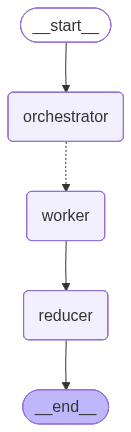

In [ ]:
# Main Graph
graph = StateGraph(BlogState)

graph.add_node('orchestrator', orchestrator)
graph.add_node('worker', worker)
graph.add_node('reducer', reducer)

graph.add_edge(START, 'orchestrator')
graph.add_conditional_edges('orchestrator', distribute_tasks, ['worker'])
graph.add_edge('worker', 'reducer')
graph.add_edge('reducer', END)

chatbot = graph.compile()
chatbot

# Running

In [24]:
user_query = chatbot.invoke({
    'topic' : 'Write blog on the topic of Agentic AI.',
    'sections' : [] # This list is the place where all our blog content is located.
})

user_query

{'topic': 'Write blog on the topic of Agentic AI.',
 'plan': Plan(blog_title='Unlocking the Power of Agentic AI: A Comprehensive Guide', tasks=[Task(id=1, title='Introduction to Agentic AI: Why It Matters Now', description='This section covers the current state of AI and why Agentic AI is the next significant step, including its potential to revolutionize industries and improve daily life', goal="Readers will understand the importance and relevance of Agentic AI in today's technological landscape", target_words=500, bullets=['Define Agentic AI and its core principles', 'Discuss current AI limitations that Agentic AI addresses', 'Explore potential applications across various industries', 'Introduce key benefits such as autonomy and decision-making', 'Highlight the role of Agentic AI in future technological advancements']), Task(id=2, title='Foundations of Agentic AI: Core Concepts and Definitions', description='This section delves into the fundamental concepts and definitions necessary 